# Accuracy Is Not Robustness
### Measuring and Defending Against Realistic Evasion Attacks on Gradient-Boosted Phishing Website Detectors

**Authors:** Jatin Kumar and Nisarg Chasmawala
**Institution:** Birmingham City University

---

## Objective

Phishing detectors built on gradient-boosted trees are routinely reported at 97–99% accuracy,
which makes the problem look solved. This notebook tests whether that number actually means
anything to a defender.

The question we ask is simple: **if an attacker edits only the parts of a URL and page that they
themselves author, how far does detection fall?** We answer it by attacking four trained detectors
under an explicit threat model and measuring what survives.

Specifically we:

1. Train **Random Forest, XGBoost, LightGBM and CatBoost** on two public phishing datasets.
2. Split every feature into **attacker-mutable** (the URL string and page markup) and
   **attacker-immutable** (host, DNS, registration age, TLS certificate).
3. Attack the detectors two ways: a **transfer-based PGD** attack through a differentiable
   surrogate, and a **constrained decision-based Boundary attack** that only ever sees hard labels.
4. Explain the results using **mutable-importance share**, i.e. how much of a model's decision
   power sits in features the attacker controls.
5. Try **adversarial training** as a defence, and validate it against an attacker it was *not*
   trained on.

---

## Datasets

| | Dataset A | Dataset B |
|---|---|---|
| **Source** | Tan (2018), Mendeley Data | Vrbančič et al. (2020), *Data in Brief* 33:106438 |
| **Samples** | 10,000 (balanced) | 58,645 → 57,405 after removing duplicates |
| **Features** | 48 numeric | 111 numeric |
| **Schema** | URL + page content only | URL + host, DNS, registration time, TLS |
| **Mutable / immutable** | 19 / 29 | 76 / 35 |

The two schemas barely overlap, which is deliberate. If a finding shows up on both, it is unlikely
to be an artefact of one particular feature-engineering choice.

**Download links (for reference — this notebook loads both automatically):**
- Dataset A: https://data.mendeley.com/datasets/h3cgnj8hft/1
- Dataset B: https://github.com/GregaVrbancic/Phishing-Dataset

> **No upload needed.** Dataset A is embedded directly in this notebook as a compressed blob, and
> Dataset B is pulled from GitHub at runtime. Just press *Runtime → Run all*.

---

## Runtime

Roughly **8–15 minutes** end to end on a standard Colab CPU runtime. No GPU required.
(Runtime scales with the number of CPU cores Colab gives you.)
The two slowest parts are the Boundary attack on Dataset B and the five-seed reliability check;
both are clearly marked below.

## Step 1 — Install the one package Colab is missing

Colab already ships with scikit-learn, XGBoost and LightGBM. CatBoost is the only one we have to
add. We install it quietly and only if it isn't already there, so re-running this cell is cheap.

In [1]:
# CatBoost isn't preinstalled on Colab, so grab it. Everything else is already available.
import importlib, subprocess, sys

def ensure(pkg, pip_name=None):
    """
    Import a package, installing it first if it's missing.

    We try a plain pip install first. Some managed environments refuse that and want
    --break-system-packages, so we fall back to it rather than letting the cell die.
    """
    try:
        importlib.import_module(pkg)
        print(f"  {pkg:<10} already available")
        return True
    except ImportError:
        pass

    print(f"  {pkg:<10} not found, installing...")
    for extra in ([], ["--break-system-packages"]):
        cmd = [sys.executable, "-m", "pip", "install", "-q", pip_name or pkg] + extra
        try:
            subprocess.run(cmd, check=True, capture_output=True)
            importlib.invalidate_caches()
            importlib.import_module(pkg)
            print(f"  {pkg:<10} installed")
            return True
        except Exception:
            continue

    print(f"  {pkg:<10} COULD NOT INSTALL - see note below")
    return False

print("Checking packages...")
ok = all([ensure("numpy"), ensure("pandas"), ensure("sklearn", "scikit-learn"),
          ensure("matplotlib"), ensure("xgboost"), ensure("lightgbm"), ensure("catboost")])

print()
print("All dependencies satisfied." if ok else
      "Something failed to install. On Colab try: Runtime > Restart session, then re-run.")

Checking packages...
  numpy      already available
  pandas     already available
  sklearn    already available
  matplotlib already available
  xgboost    already available
  lightgbm   already available
  catboost   not found, installing...
  catboost   installed

All dependencies satisfied.


### Imports and a fixed random seed

We pin a single seed (42) so the numbers below reproduce exactly. Everything downstream that has
any randomness in it — the train/test split, model initialisation, the attack's random search —
derives from this.

In [2]:
import numpy as np, pandas as pd, time, json, warnings, gzip, base64, io, urllib.request
warnings.filterwarnings("ignore")   # LightGBM and sklearn are chatty; we don't need the noise

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib
import matplotlib.pyplot as plt

SEED = 42                      # one seed to rule them all, for reproducibility
np.random.seed(SEED)

# ---------------------------------------------------------------------------
# Experiment settings. These are the exact values used in the report, so leave
# them alone if you want to reproduce the published tables.
#
# If you just want a quick demo run, set N_ATTACK = 150. The story comes out the
# same, the numbers shift slightly, and it finishes roughly three times faster.
# ---------------------------------------------------------------------------
N_ATTACK     = 400     # phishing pages handed to the Boundary attack
BOUNDARY_STEPS = 100   # refinement iterations in the Boundary attack
PGD_STEPS    = 30      # projected-gradient steps in the transfer attack

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("Setup complete. numpy", np.__version__, "| pandas", pd.__version__)

Setup complete. numpy 2.0.2 | pandas 2.2.2


## Step 2 — Load Dataset A (Tan, 2018)

Dataset A lives on Mendeley behind a download page, which makes automated fetching unreliable. To
guarantee this notebook never fails on a missing file, the CSV is **embedded directly below** as a
gzip-compressed, base64-encoded string. We decompress it in memory straight into a DataFrame.

We also print an MD5 checksum so you can confirm the data is byte-identical to the original file.

In [3]:
# The full CSV, gzipped and base64-encoded. Decoding it in memory means no upload step
# and no broken download link -- the notebook is completely self-contained.
DATASET_A_B64 = "..."
print("Embedded blob length:", len(DATASET_A_B64), "characters")

Embedded blob length: 272060 characters


In [4]:
import hashlib

# Decode -> decompress -> read straight into pandas. Nothing touches the filesystem.
raw_a = gzip.decompress(base64.b64decode(DATASET_A_B64))
print("Decompressed size:", len(raw_a), "bytes")
print("MD5 checksum     :", hashlib.md5(raw_a).hexdigest())

dfA = pd.read_csv(io.BytesIO(raw_a))
print("\nDataset A shape:", dfA.shape)
dfA.head(3)

Decompressed size: 1416307 bytes
MD5 checksum     : 971f9ccd17276801538a7573d4caae66

Dataset A shape: (10000, 50)


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1


### A quick look at what's inside

The label column is `CLASS_LABEL` (1 = phishing, 0 = legitimate) and there's an `id` column we
don't want as a feature. Everything else is a numeric descriptor of the URL or the page content.

In [5]:
print("Columns:", len(dfA.columns))
print("Label balance (1 = phishing):")
print(dfA["CLASS_LABEL"].value_counts().to_string())
print("\nAny missing values?", dfA.isna().sum().sum())
print("First 12 feature names:", [c for c in dfA.columns if c not in ("id", "CLASS_LABEL")][:12])

Columns: 50
Label balance (1 = phishing):
CLASS_LABEL
1    5000
0    5000

Any missing values? 0
First 12 feature names: ['NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumQueryComponents', 'NumAmpersand']


## Step 3 — Download Dataset B (Vrbančič et al., 2020)

Dataset B is hosted on GitHub, so we can pull it directly. This one is about six times larger and,
crucially, its feature schema includes **host, DNS, domain-registration and TLS attributes** —
signals an attacker cannot simply invent by writing a web page. That contrast is the whole point of
using two datasets.

The download is wrapped in a retry so a flaky connection doesn't kill the run.

In [6]:
DATASET_B_URL = "https://raw.githubusercontent.com/GregaVrbancic/Phishing-Dataset/master/dataset_small.csv"

def fetch_csv(url, attempts=3):
    """Download a CSV into a DataFrame, retrying a couple of times if the network hiccups."""
    last_err = None
    for i in range(attempts):
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                data = r.read()
            print(f"Downloaded {len(data):,} bytes on attempt {i+1}")
            return pd.read_csv(io.BytesIO(data))
        except Exception as e:
            last_err = e
            print(f"Attempt {i+1} failed ({e}), retrying...")
            time.sleep(3)
    raise RuntimeError(f"Could not download Dataset B: {last_err}")

dfB = fetch_csv(DATASET_B_URL)
print("\nDataset B shape (raw):", dfB.shape)
dfB.head(3)

Downloaded 16,028,060 bytes on attempt 1

Dataset B shape (raw): (58645, 112)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,2,0,0,0,0,0,0,0,0,0,...,1,4,2,3598,0,0,0,0,0,0
1,4,0,0,2,0,0,0,0,0,0,...,1,4,1,3977,1,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,1,2,1,10788,0,0,0,0,0,0


### Removing duplicates

The raw file has some exact duplicate rows. Leaving them in would leak identical samples across the
train/test split and inflate the scores, so we drop them first. The paper reports 57,405 rows after
this step.

In [7]:
before = len(dfB)
dfB = dfB.drop_duplicates().reset_index(drop=True)
print(f"Rows before de-duplication: {before:,}")
print(f"Rows after  de-duplication: {len(dfB):,}   (removed {before - len(dfB):,})")

print("\nLabel balance (1 = phishing):")
print(dfB["phishing"].value_counts().to_string())
print(f"Phishing proportion: {dfB['phishing'].mean():.3f}")

Rows before de-duplication: 58,645
Rows after  de-duplication: 57,405   (removed 1,240)

Label balance (1 = phishing):
phishing
1    30497
0    26908
Phishing proportion: 0.531


## Step 4 — The key modelling decision: mutable vs immutable features

This is the heart of the whole study, so it's worth being precise about it.

A feature is **mutable** if the attacker sets it just by choosing a URL and writing the page. Things
like how many dots are in the hostname, how long the path is, or what fraction of hyperlinks point
off-site. The attacker controls all of that for free.

A feature is **immutable** if it reflects hosting infrastructure or registration history. Domain
age, name-server counts, TLS certificate state. An attacker can't fabricate those by editing markup;
changing them costs real money, time, or both.

Our threat model only ever lets the attacker touch the mutable columns.

In [8]:
# --- Dataset A: 19 of 48 features are attacker-authored ---
MUTABLE_A = [
    "NumDots", "SubdomainLevel", "PathLevel", "UrlLength", "NumDash",
    "NumDashInHostname", "NumUnderscore", "NumPercent", "NumQueryComponents",
    "NumAmpersand", "NumHash", "NumNumericChars", "HostnameLength", "PathLength",
    "QueryLength", "NumSensitiveWords", "PctExtHyperlinks", "PctExtResourceUrls",
    "PctNullSelfRedirectHyperlinks",
]

featsA = [c for c in dfA.columns if c not in ("id", "CLASS_LABEL")]
XA = dfA[featsA].values.astype(float)
yA = dfA["CLASS_LABEL"].values.astype(int)

mutA_present = [f for f in MUTABLE_A if f in featsA]
print(f"Dataset A -> {len(featsA)} features total")
print(f"   mutable   : {len(mutA_present)}")
print(f"   immutable : {len(featsA) - len(mutA_present)}")

Dataset A -> 48 features total
   mutable   : 19
   immutable : 29


In [9]:
# --- Dataset B: mutable features are the per-segment lexical counts ---
# Anything counting characters in the url / directory / file / params is attacker-authored.
# Everything else (domain age, nameservers, TLS, ASN...) stays frozen.
featsB = [c for c in dfB.columns if c != "phishing"]

def is_mutable_B(col):
    if col.endswith(("_url", "_directory", "_file", "_params")):
        return True
    return col in ("directory_length", "file_length", "params_length")

MUTABLE_B = [c for c in featsB if is_mutable_B(c)]

XB = dfB[featsB].values.astype(float)
yB = dfB["phishing"].values.astype(int)

print(f"Dataset B -> {len(featsB)} features total")
print(f"   mutable   : {len(MUTABLE_B)}")
print(f"   immutable : {len(featsB) - len(MUTABLE_B)}")
print("\nExamples of frozen (immutable) features:")
print("  ", [c for c in featsB if c not in MUTABLE_B][:8])

Dataset B -> 111 features total
   mutable   : 76
   immutable : 35

Examples of frozen (immutable) features:
   ['qty_dot_domain', 'qty_hyphen_domain', 'qty_underline_domain', 'qty_slash_domain', 'qty_questionmark_domain', 'qty_equal_domain', 'qty_at_domain', 'qty_and_domain']


## Step 5 — The validity projection

An adversarial example is only interesting if it corresponds to a page someone could actually build.
A perturbation that sets "number of dots" to 2.7, or pushes URL length to a value never seen in
training, is a mathematical curiosity rather than a security problem.

So after every attack step we push the candidate back into the space of legal feature vectors. The
projection Π does three things:

1. **Clip** each feature to the range observed in the training data.
2. **Round** count features back to whole numbers.
3. **Freeze** the immutable features at their original values.

This is what separates a realistic attack from a purely theoretical one.

In [10]:
def make_project(mu, sd, lo, hi, int_mask):
    """
    Build the validity projection.

    We work in standardised space (that's what the models see), so we convert back to raw
    units, apply the constraints there, then convert forward again.
    """
    def project(x):
        raw = x * sd + mu                          # standardised -> real units
        raw = np.clip(raw, lo, hi)                 # stay inside the observed range
        raw[:, int_mask] = np.round(raw[:, int_mask])   # counts must be whole numbers
        return (raw - mu) / sd                     # back to standardised space
    return project

## Step 6 — The four detectors

These are the hyperparameters used in the paper. They are deliberately ordinary: the point of the
study is not to squeeze out the last 0.1% of accuracy, it's to show that accuracy stops being
informative once an attacker is in the picture.

In [11]:
def make_models(seed):
    """The four tree ensembles we attack. Identical settings on both datasets."""
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=250, max_features="sqrt", random_state=seed, n_jobs=-1),

        "XGBoost": XGBClassifier(
            n_estimators=350, max_depth=6, learning_rate=0.04, subsample=0.9,
            colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
            random_state=seed, n_jobs=-1),

        "LightGBM": LGBMClassifier(
            n_estimators=400, learning_rate=0.04, num_leaves=63, subsample=0.9,
            colsample_bytree=0.8, reg_lambda=1.0, random_state=seed,
            n_jobs=-1, verbose=-1),

        "CatBoost": CatBoostClassifier(
            iterations=350, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
            random_seed=seed, verbose=0, thread_count=-1),
    }

def metrics(model, Xs, yt):
    """The five clean-performance numbers reported in the paper."""
    pred  = model.predict(Xs)
    proba = model.predict_proba(Xs)[:, 1]
    return dict(acc=accuracy_score(yt, pred),
                prec=precision_score(yt, pred),
                rec=recall_score(yt, pred),
                f1=f1_score(yt, pred),
                auc=roc_auc_score(yt, proba))

print("Model factory ready.")

Model factory ready.


## Step 7 — A differentiable surrogate for the transfer attack

Tree ensembles have no gradients, so we can't run PGD on them directly. The standard workaround is
to train a small differentiable model on the same data, compute gradients there, and transfer the
resulting perturbations across.

This MLP is written in plain NumPy — one hidden layer, 128 ReLU units. It is **only** ever used as
an attack surrogate. It is never evaluated as a detector.

In [12]:
class MLP:
    """A minimal NumPy MLP. Used purely to generate gradients for the transfer attack."""

    def __init__(self, d, h=128, seed=0):
        r = np.random.RandomState(seed)
        # He initialisation, since we're using ReLU
        self.W1 = r.randn(d, h) * np.sqrt(2 / d); self.b1 = np.zeros(h)
        self.W2 = r.randn(h, 1) * np.sqrt(2 / h); self.b2 = np.zeros(1)

    def fwd(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)              # ReLU
        self.z2 = self.a1 @ self.W2 + self.b2
        self.p  = 1 / (1 + np.exp(-self.z2))          # sigmoid
        return self.p

    def fit(self, X, y, ep=200, lr=0.05, bs=256):
        y = y.reshape(-1, 1).astype(float); n = len(X)
        for _ in range(ep):
            idx = np.random.permutation(n)
            for i in range(0, n, bs):
                b = idx[i:i + bs]; xb = X[b]; yb = y[b]
                p = self.fwd(xb)
                g2 = (p - yb) / len(b)                          # dL/dz2
                dW2 = self.a1.T @ g2; db2 = g2.sum(0)
                g1 = (g2 @ self.W2.T) * (self.z1 > 0)           # backprop through ReLU
                dW1 = xb.T @ g1; db1 = g1.sum(0)
                self.W2 -= lr * dW2; self.b2 -= lr * db2
                self.W1 -= lr * dW1; self.b1 -= lr * db1
        return self

    def igrad(self, X, y):
        """Gradient of the loss with respect to the *input* -- this is what PGD needs."""
        y = y.reshape(-1, 1).astype(float)
        p = self.fwd(X)
        g2 = (p - y)
        g1 = (g2 @ self.W2.T) * (self.z1 > 0)
        return g1 @ self.W1.T

    def predict(self, X):
        return (self.fwd(X).ravel() >= 0.5).astype(int)

print("Surrogate class ready.")

Surrogate class ready.


## Step 8 — The constrained Boundary attack

The transfer attack has one weakness as evidence: if it works, a sceptic can say the surrogate
happened to be a good match, and if it fails, they can say the surrogate was bad. So we also run an
attacker that never sees gradients, scores or model internals — only the **hard label** the detector
returns.

It works in two phases:

1. **Warm start.** Random search over the mutable features at increasing magnitudes, keeping the
   smallest-L2 point that already flips the label.
2. **Refinement.** Repeatedly step that point back toward the original while staying on the
   "legitimate" side, with small sideways moves to escape ridges.

Every candidate goes through the validity projection, so each query corresponds to a page that could
genuinely exist. What we report is the **median L2 needed to evade** — effectively the price the
attacker pays.

In [13]:
def boundary_attack(model, Xorig, project, mask, seed=0, steps=100,
                    warm_mags=(0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0),
                    warm_K=14):
    """
    Decision-based evasion using hard labels only.
    Returns, per sample, whether it could be evaded at all and how big the perturbation had to be.
    """
    rs = np.random.RandomState(seed)
    N, D = Xorig.shape
    mut_idx = np.where(mask > 0)[0]; nm = len(mut_idx)

    best  = np.full(N, np.inf)
    xbest = Xorig.copy()
    found = np.zeros(N, bool)

    # Some samples may already be misclassified -- those cost the attacker nothing.
    ok0 = model.predict(Xorig) == 0
    found |= ok0; best[ok0] = 0.0

    # ---- Phase 1: warm start via random search ----
    for mag in warm_mags:
        for _ in range(warm_K):
            d = np.zeros((N, D))
            d[:, mut_idx] = np.sign(rs.uniform(-1, 1, (N, nm))) * mag
            cand = project(Xorig + d)
            ok = model.predict(cand) == 0
            l2 = np.linalg.norm(cand - Xorig, axis=1)
            better = ok & (l2 < best)
            xbest[better] = cand[better]; best[better] = l2[better]
            found |= ok

    # ---- Phase 2: walk back toward the original, staying adversarial ----
    eps_step = 0.3
    for t in range(steps):
        act = np.where(found)[0]
        if len(act) == 0:
            break
        xa, xo = xbest[act], Xorig[act]

        # Shrink toward the original point
        cand = project(xa + eps_step * (xo - xa))
        ok = model.predict(cand) == 0
        l2 = np.linalg.norm(cand - xo, axis=1)
        imp = ok & (l2 < best[act])
        gi = act[imp]; xbest[gi] = cand[imp]; best[gi] = l2[imp]

        # Small orthogonal nudge, so we don't get stuck on a ridge
        d = xo - xbest[act]
        dn = np.linalg.norm(d, axis=1, keepdims=True) + 1e-12
        du = d / dn
        n = rs.randn(len(act), D) * mask
        n = n - np.sum(n * du, axis=1, keepdims=True) * du     # make it perpendicular
        nn = np.linalg.norm(n, axis=1, keepdims=True) + 1e-12
        cand2 = project(xbest[act] + n / nn * (0.1 * dn))
        ok2 = model.predict(cand2) == 0
        l22 = np.linalg.norm(cand2 - xo, axis=1)
        imp2 = ok2 & (l22 < best[act])
        gi2 = act[imp2]; xbest[gi2] = cand2[imp2]; best[gi2] = l22[imp2]

        # Adapt the step size based on how often shrinking worked
        acc = imp.mean() if len(imp) else 0
        eps_step *= 1.05 if acc > 0.3 else 0.9
        eps_step = float(np.clip(eps_step, 1e-3, 0.9))

    l2 = np.where(found, best, np.inf)
    return dict(found=found, l2=l2, queries=int(len(warm_mags) * warm_K + steps * 2))


def robust_curve(l2, taus):
    """Fraction of phishing pages still detected when the attacker's budget is tau."""
    return [float(np.mean(l2 > t)) for t in taus]

print("Boundary attack ready.")

Boundary attack ready.


## Step 9 — Putting it together into one pipeline

This function runs the whole experiment for a given dataset: split, standardise, train, evaluate
clean, attack twice, then optionally build and test the defence. Reading it top to bottom is
basically reading the Methodology section of the paper.

One detail worth flagging: we attack **only the phishing class**. A false negative is the
security-critical error here — a phishing page that slips through does real damage, whereas a
legitimate page flagged as phishing is an annoyance. So "detection rate" below always means
*recall on phishing under attack*.

In [14]:
def run_pipeline(X, y, feats, mutable, seed=SEED, n_attack=N_ATTACK, bsteps=BOUNDARY_STEPS,
                 EPS=(0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0),
                 TAUS=(0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0),
                 do_boundary=True, do_defense=True, verbose=True):

    t0 = time.time()

    # --- split and standardise (fit the scaler on training data only) ---
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    mu, sd = sc.mean_, sc.scale_

    # --- everything the validity projection needs ---
    int_mask = np.array([np.allclose(X[:, j], np.round(X[:, j])) for j in range(len(feats))])
    lo, hi = Xtr.min(0), Xtr.max(0)
    mask = np.zeros(len(feats))
    midx = [feats.index(f) for f in mutable if f in feats]
    mask[midx] = 1.0
    project = make_project(mu, sd, lo, hi, int_mask)

    # --- train the four detectors and score them on clean data ---
    models, fitted, clean = make_models(seed), {}, {}
    for name, m in models.items():
        m.fit(Xtr_s, ytr)
        fitted[name] = m
        clean[name] = metrics(m, Xte_s, yte)
        if verbose:
            print(f"  trained {name:<13} clean acc = {clean[name]['acc']:.4f}")

    # --- surrogate + transfer PGD ---
    surr = MLP(len(feats), seed=seed).fit(Xtr_s, ytr)

    def pgd(x0, eps, steps=PGD_STEPS):
        """PGD on the surrogate, restricted to mutable features and projected each step."""
        x = x0.copy(); a = 2.5 * eps / steps; yl = np.ones(len(x0))
        for _ in range(steps):
            g = surr.igrad(x, yl)
            x = x + a * np.sign(g) * mask          # only move mutable dims
            x = np.clip(x, x0 - eps, x0 + eps)     # stay inside the L-inf ball
            x = x * mask + x0 * (1 - mask)         # hard-reset the immutable dims
            x = project(x)                          # and keep it a legal page
        return x

    ph = yte == 1
    Xph, yph = Xte_s[ph], yte[ph]

    transfer = {n: [] for n in fitted}
    for eps in EPS:
        Xa = Xph if eps == 0 else pgd(Xph, eps)
        for n, m in fitted.items():
            transfer[n].append(float(accuracy_score(yph, m.predict(Xa))))

    out = dict(seed=int(seed), n_train=int(len(Xtr)), n_test=int(len(Xte)),
               n_feat=len(feats), n_mutable=len(midx), clean=clean,
               eps=list(EPS), transfer=transfer)

    # --- decision-based attack ---
    if do_boundary:
        Xatt = Xph[:n_attack]; taus = list(TAUS); bb = {}
        for n, m in fitted.items():
            r = boundary_attack(m, Xatt, project, mask, seed=seed, steps=bsteps)
            fin = np.isfinite(r["l2"])
            bb[n] = dict(evadable=float(r["found"].mean()),
                         med_l2=float(np.median(r["l2"][fin])) if fin.any() else None,
                         robust=robust_curve(r["l2"], taus),
                         queries=int(r["queries"]))
            if verbose:
                print(f"  boundary {n:<13} evadable = {bb[n]['evadable']:.3f} "
                      f"median L2 = {bb[n]['med_l2']:.2f}")
        out["taus"] = taus; out["boundary"] = bb

    # --- adversarial training, then re-attack with the *independent* attacker ---
    if do_defense:
        Xp = Xtr_s[ytr == 1]
        Xadv = np.vstack([pgd(Xp, e) for e in (0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5)])
        Xaug = np.vstack([Xtr_s, Xadv])
        yaug = np.concatenate([ytr, np.ones(len(Xadv), int)])

        dm = LGBMClassifier(n_estimators=400, learning_rate=0.04, num_leaves=63, subsample=0.9,
                            colsample_bytree=0.8, reg_lambda=1.0, random_state=seed,
                            n_jobs=-1, verbose=-1).fit(Xaug, yaug)

        dclean = metrics(dm, Xte_s, yte)
        drob = [float(accuracy_score(yph, dm.predict(Xph if eps == 0 else pgd(Xph, eps))))
                for eps in EPS]

        dbb = None
        if do_boundary:
            r = boundary_attack(dm, Xph[:n_attack], project, mask, seed=seed, steps=bsteps)
            dbb = dict(evadable=float(r["found"].mean()),
                       med_l2=float(np.median(r["l2"][np.isfinite(r["l2"])])),
                       robust=robust_curve(r["l2"], list(TAUS)))

        out["defense"] = dict(clean=dclean, undef=transfer["LightGBM"],
                              defended=drob, boundary=dbb)

    out["secs"] = round(time.time() - t0, 1)
    return out

print("Pipeline ready.")

Pipeline ready.


## Step 10 — Run the full experiment on Dataset A

This takes roughly a minute. Watch the clean accuracies as they print: every model lands around
98.5%, which is exactly the "looks solved" picture we're about to take apart.

In [15]:
print("=== Dataset A (Tan, 2018) ===")
resA = run_pipeline(XA, yA, featsA, MUTABLE_A, seed=SEED)
print(f"\nFinished in {resA['secs']}s")
print(f"Train / test split: {resA['n_train']:,} / {resA['n_test']:,}")
print(f"Features: {resA['n_feat']}  (mutable: {resA['n_mutable']})")

=== Dataset A (Tan, 2018) ===
  trained RandomForest  clean acc = 0.9850
  trained XGBoost       clean acc = 0.9875
  trained LightGBM      clean acc = 0.9855
  trained CatBoost      clean acc = 0.9865
  boundary RandomForest  evadable = 0.948 median L2 = 2.64
  boundary XGBoost       evadable = 0.990 median L2 = 1.85
  boundary LightGBM      evadable = 0.990 median L2 = 2.03
  boundary CatBoost      evadable = 0.950 median L2 = 1.58

Finished in 82.6s
Train / test split: 8,000 / 2,000
Features: 48  (mutable: 19)


## Step 11 — Run the same experiment on Dataset B

Same code, same threat model, different feature schema. This one is bigger so it takes around
three minutes. Expect *lower* clean accuracy than Dataset A — and pay attention to what happens to
the attack numbers anyway.

In [16]:
print("=== Dataset B (Vrbancic et al., 2020) ===")
resB = run_pipeline(XB, yB, featsB, MUTABLE_B, seed=SEED)
print(f"\nFinished in {resB['secs']}s")
print(f"Train / test split: {resB['n_train']:,} / {resB['n_test']:,}")
print(f"Features: {resB['n_feat']}  (mutable: {resB['n_mutable']})")

=== Dataset B (Vrbancic et al., 2020) ===
  trained RandomForest  clean acc = 0.9571
  trained XGBoost       clean acc = 0.9498
  trained LightGBM      clean acc = 0.9580
  trained CatBoost      clean acc = 0.9455
  boundary RandomForest  evadable = 0.578 median L2 = 5.86
  boundary XGBoost       evadable = 0.900 median L2 = 5.85
  boundary LightGBM      evadable = 0.807 median L2 = 5.71
  boundary CatBoost      evadable = 0.812 median L2 = 5.96

Finished in 209.1s
Train / test split: 45,924 / 11,481
Features: 111  (mutable: 76)


## Result 1 — Clean performance (Table 4 in the paper)

Here's the "problem is solved" view. On Dataset A everything clears 98.5% accuracy with ROC-AUC
above 0.998. On Dataset B the numbers sit around 95% with AUC above 0.988.

Look at how tightly packed the models are. The gaps between them are smaller than what you'd get by
changing the random seed. On this evidence there is no reason to prefer any one of these detectors
over another — which is precisely the problem.

In [17]:
MODELS = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]

def clean_table(res, title):
    rows = []
    for m in MODELS:
        c = res["clean"][m]
        rows.append({"Model": m, "Accuracy": round(c["acc"], 4), "Precision": round(c["prec"], 4),
                     "Recall": round(c["rec"], 4), "F1": round(c["f1"], 4),
                     "ROC-AUC": round(c["auc"], 4)})
    df = pd.DataFrame(rows)
    print(f"\n{title}")
    print(df.to_string(index=False))
    return df

tabA = clean_table(resA, "Dataset A (Tan, 2018) - clean test performance")
tabB = clean_table(resB, "Dataset B (Vrbancic et al., 2020) - clean test performance")


Dataset A (Tan, 2018) - clean test performance
       Model  Accuracy  Precision  Recall     F1  ROC-AUC
RandomForest    0.9850     0.9879   0.982 0.9850   0.9989
     XGBoost    0.9875     0.9860   0.989 0.9875   0.9988
    LightGBM    0.9855     0.9860   0.985 0.9855   0.9988
    CatBoost    0.9865     0.9841   0.989 0.9865   0.9985

Dataset B (Vrbancic et al., 2020) - clean test performance
       Model  Accuracy  Precision  Recall     F1  ROC-AUC
RandomForest    0.9571     0.9550  0.9647 0.9599   0.9916
     XGBoost    0.9498     0.9525  0.9531 0.9528   0.9902
    LightGBM    0.9580     0.9611  0.9598 0.9605   0.9922
    CatBoost    0.9455     0.9468  0.9508 0.9488   0.9888


## Result 2 — Transfer attack (Table 5 in the paper)

Now we let the attacker perturb the mutable features and watch detection fall.

The two datasets behave completely differently:

- **Dataset A collapses.** A perturbation of just 0.05 standardised units drops detection from about
  98.6% to the mid-60s, and then it flattens out. The damage is done almost immediately; extra
  budget buys the attacker very little because there was so little resistance to begin with.
- **Dataset B degrades gracefully.** The same attack barely moves it at 0.05, and even at a budget
  of 1.0 detection is still between 73% and 88%.

Same models, same code, same attack. The only thing that changed is the feature representation.

In [18]:
def transfer_table(res, tag):
    eps = res["eps"]
    rows = []
    for m in MODELS:
        row = {"Dataset": tag, "Model": m}
        row.update({f"e={e}": round(v * 100, 1) for e, v in zip(eps, res["transfer"][m])})
        rows.append(row)
    return pd.DataFrame(rows)

trans = pd.concat([transfer_table(resA, "A"), transfer_table(resB, "B")], ignore_index=True)
print("Phishing detection rate (%) under the transfer attack\n")
print(trans.to_string(index=False))

Phishing detection rate (%) under the transfer attack

Dataset        Model  e=0.0  e=0.05  e=0.1  e=0.2  e=0.3  e=0.5  e=0.75  e=1.0
      A RandomForest   98.2    68.4   67.9   67.2   67.2   67.4    66.7   66.8
      A      XGBoost   98.9    69.3   69.2   69.7   69.4   71.5    69.5   69.5
      A     LightGBM   98.5    69.3   69.1   69.7   69.3   70.4    69.0   67.8
      A     CatBoost   98.9    66.5   66.4   66.1   67.1   68.3    67.3   67.4
      B RandomForest   96.5    96.5   96.5   95.6   93.5   90.2    89.0   88.2
      B      XGBoost   95.3    95.3   95.3   93.8   88.7   83.1    77.0   73.1
      B     LightGBM   96.0    96.0   96.0   94.0   89.8   83.7    78.4   75.6
      B     CatBoost   95.1    95.1   95.1   93.7   89.5   83.2    79.5   77.4


### What that actually means in practice

Percentages can feel abstract, so let's count actual pages. We take LightGBM on Dataset A, look at
its confusion matrix on clean data, then again under a budget of 0.3.

In [19]:
# Rebuild just enough state to inspect LightGBM on Dataset A directly.
Xtr, Xte, ytr, yte = train_test_split(XA, yA, test_size=0.2, random_state=SEED, stratify=yA)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
mu, sd = sc.mean_, sc.scale_

int_mask_A = np.array([np.allclose(XA[:, j], np.round(XA[:, j])) for j in range(len(featsA))])
loA, hiA = Xtr.min(0), Xtr.max(0)
maskA = np.zeros(len(featsA))
maskA[[featsA.index(f) for f in MUTABLE_A if f in featsA]] = 1.0
projectA = make_project(mu, sd, loA, hiA, int_mask_A)

lgbm_A = LGBMClassifier(n_estimators=400, learning_rate=0.04, num_leaves=63, subsample=0.9,
                        colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED,
                        n_jobs=-1, verbose=-1).fit(Xtr_s, ytr)

surr_A = MLP(len(featsA), seed=SEED).fit(Xtr_s, ytr)

def pgd_A(x0, eps, steps=30):
    x = x0.copy(); a = 2.5 * eps / steps; yl = np.ones(len(x0))
    for _ in range(steps):
        g = surr_A.igrad(x, yl)
        x = x + a * np.sign(g) * maskA
        x = np.clip(x, x0 - eps, x0 + eps)
        x = x * maskA + x0 * (1 - maskA)
        x = projectA(x)
    return x

cm_clean = confusion_matrix(yte, lgbm_A.predict(Xte_s))
Xph_A = Xte_s[yte == 1]
adv = pgd_A(Xph_A, 0.3)
pred_adv = lgbm_A.predict(adv)
cm_adv = confusion_matrix(np.ones(len(pred_adv), int), pred_adv, labels=[0, 1])

print("Clean confusion matrix (rows = actual, cols = predicted):")
print(cm_clean)
print(f"  -> only {cm_clean[0,1] + cm_clean[1,0]} of {len(yte)} pages misclassified\n")

print("Under attack (phishing pages only, eps = 0.3):")
print(cm_adv)
print(f"  -> {cm_adv[1,0]} of {len(pred_adv)} phishing pages now pass as legitimate")

Clean confusion matrix (rows = actual, cols = predicted):
[[986  14]
 [ 15 985]]
  -> only 29 of 2000 pages misclassified

Under attack (phishing pages only, eps = 0.3):
[[  0   0]
 [308 692]]
  -> 308 of 1000 phishing pages now pass as legitimate


## Result 3 — The decision-based attacker agrees (Table 6 in the paper)

A reasonable objection to the last result is that the surrogate might just be unusually well matched
to these models. So here is the Boundary attack, which never sees a gradient or a probability —
only the final label.

It tells the same story, and adds two useful numbers:

- **Evadable**: what fraction of phishing pages can be pushed past the boundary *at all* while
  staying inside legal feature ranges.
- **Median L2**: how large a perturbation the attacker needs. Bigger means more robust.

Note the Random Forest row on Dataset B: only about 58% of pages are evadable. For the other 40%+,
no amount of rewriting the 76 mutable features flips the verdict, because the decision is anchored
in features the attacker doesn't own.

In [20]:
def boundary_table(res, tag):
    taus = res["taus"]
    i02, i05, i20 = taus.index(0.2), taus.index(0.5), taus.index(2.0)
    rows = []
    for m in MODELS:
        b = res["boundary"][m]
        rows.append({"Dataset": tag, "Model": m,
                     "Evadable": round(b["evadable"], 3),
                     "Median L2": round(b["med_l2"], 2),
                     "Det@0.2 (%)": round(b["robust"][i02] * 100, 1),
                     "Det@0.5 (%)": round(b["robust"][i05] * 100, 1),
                     "Det@2.0 (%)": round(b["robust"][i20] * 100, 1)})
    return pd.DataFrame(rows)

bnd = pd.concat([boundary_table(resA, "A"), boundary_table(resB, "B")], ignore_index=True)
print("Constrained decision-based Boundary attack\n")
print(bnd.to_string(index=False))

print("\nCost of evasion, side by side:")
for m in MODELS:
    print(f"  {m:<13} A: {resA['boundary'][m]['med_l2']:.2f}   "
          f"B: {resB['boundary'][m]['med_l2']:.2f}")

Constrained decision-based Boundary attack

Dataset        Model  Evadable  Median L2  Det@0.2 (%)  Det@0.5 (%)  Det@2.0 (%)
      A RandomForest     0.948       2.64         67.2         65.5         58.8
      A      XGBoost     0.990       1.85         66.2         64.8         47.8
      A     LightGBM     0.990       2.03         67.8         66.5         50.7
      A     CatBoost     0.950       1.58         64.2         63.7         44.0
      B RandomForest     0.578       5.86         94.5         92.8         87.8
      B      XGBoost     0.900       5.85         93.5         91.0         80.0
      B     LightGBM     0.807       5.71         93.8         92.0         81.2
      B     CatBoost     0.812       5.96         92.8         90.5         86.0

Cost of evasion, side by side:
  RandomForest  A: 2.64   B: 5.86
  XGBoost       A: 1.85   B: 5.85
  LightGBM      A: 2.03   B: 5.71
  CatBoost      A: 1.58   B: 5.96


## Result 4 — Why the two datasets differ (Table 7 in the paper)

So why is the *same algorithm* fragile on one dataset and sturdy on the other?

We measure the **mutable-importance share**: add up each model's feature importances over the
mutable columns, and divide by the total. It answers "how much of this model's decision-making sits
in territory the attacker controls?"

The answer is stark for the boosted model. LightGBM puts **76%** of its importance on mutable
features in Dataset A, but only **27%** in Dataset B, where it leans on domain age, name servers and
TLS state instead.

Random Forest is a partial exception — its share is similar on both datasets, yet it's still the most
robust model on Dataset A. That's consistent with the wider point rather than against it: forests
spread importance thinly across many weak features, while boosting concentrates it on a few strong
ones, so concentration in attacker-owned territory is what really hurts.

In [21]:
def mutable_share(model, feats, mutable):
    """Share of total feature importance that sits on attacker-controlled features."""
    imp = np.asarray(model.feature_importances_, dtype=float)
    imp = imp / (imp.sum() + 1e-12)
    idx = [feats.index(f) for f in mutable if f in feats]
    return float(imp[idx].sum())

def reliance_for(df, label, drop_cols, mutable, tag):
    """
    Reliance is measured on a de-duplicated view of the data with plain, unregularised
    models. We deliberately strip subsampling and regularisation here: those shuffle
    importance around between correlated features, and we want a clean read on *where*
    the model is looking rather than the best possible fit.
    """
    d = df.drop(columns=drop_cols) if drop_cols else df.copy()
    d = d.drop_duplicates().reset_index(drop=True)
    feats = [c for c in d.columns if c != label]
    X = d[feats].values.astype(float)
    y = d[label].values.astype(int)

    Xtr, _, ytr, _ = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    Xtr_s = StandardScaler().fit_transform(Xtr)

    pair = [
        ("RandomForest", RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=-1)),
        ("LightGBM",     LGBMClassifier(n_estimators=400, learning_rate=0.04, num_leaves=63,
                                        random_state=SEED, n_jobs=-1, verbose=-1)),
    ]
    out = {}
    for name, m in pair:
        m.fit(Xtr_s, ytr)
        out[name] = mutable_share(m, feats, mutable)
        print(f"  {tag}  {name:<13} mutable-importance share = {out[name]:.3f}")
    print(f"       ({len(d):,} rows after de-duplication, {len(feats)} features)")
    return out

print("Computing feature reliance (refits two models per dataset)...\n")
relA = reliance_for(dfA, "CLASS_LABEL", ["id"], MUTABLE_A, "A")
relB = reliance_for(dfB, "phishing",    None,   MUTABLE_B, "B")

Computing feature reliance (refits two models per dataset)...

  A  RandomForest  mutable-importance share = 0.584
  A  LightGBM      mutable-importance share = 0.760
       (9,581 rows after de-duplication, 48 features)
  B  RandomForest  mutable-importance share = 0.630
  B  LightGBM      mutable-importance share = 0.269
       (57,405 rows after de-duplication, 111 features)


In [22]:
rel_rows = [
    {"Dataset": "A", "Model": "RandomForest", "Mutable features": f"{len(MUTABLE_A)} of {len(featsA)}",
     "S_mut": round(relA["RandomForest"], 3), "Median L2": round(resA["boundary"]["RandomForest"]["med_l2"], 2)},
    {"Dataset": "A", "Model": "LightGBM",     "Mutable features": f"{len(MUTABLE_A)} of {len(featsA)}",
     "S_mut": round(relA["LightGBM"], 3),     "Median L2": round(resA["boundary"]["LightGBM"]["med_l2"], 2)},
    {"Dataset": "B", "Model": "RandomForest", "Mutable features": f"{len(MUTABLE_B)} of {len(featsB)}",
     "S_mut": round(relB["RandomForest"], 3), "Median L2": round(resB["boundary"]["RandomForest"]["med_l2"], 2)},
    {"Dataset": "B", "Model": "LightGBM",     "Mutable features": f"{len(MUTABLE_B)} of {len(featsB)}",
     "S_mut": round(relB["LightGBM"], 3),     "Median L2": round(resB["boundary"]["LightGBM"]["med_l2"], 2)},
]
print("Mutable-importance share vs measured evasion cost\n")
print(pd.DataFrame(rel_rows).to_string(index=False))

Mutable-importance share vs measured evasion cost

Dataset        Model Mutable features  S_mut  Median L2
      A RandomForest         19 of 48  0.584       2.64
      A     LightGBM         19 of 48  0.760       2.03
      B RandomForest        76 of 111  0.630       5.86
      B     LightGBM        76 of 111  0.269       5.71


## Result 5 — Would this actually work on a real page? (Table 8 in the paper)

Feature-space perturbations are only convincing if a human attacker could reproduce them by editing
a web page. So we take one phishing page that LightGBM is *completely* sure about (P = 1.000) and
apply three groups of edits that any phisher could make by hand:

1. Strip out sensitive keywords like "login" or "verify".
2. Normalise the external-link and self-redirect ratios so they look like a normal site.
3. Simplify the URL punctuation — fewer dots, add a hyphen, sprinkle in some digits.
4. Adjust the URL, host and path lengths.
5. Flatten the subdomain and path depth.

Rather than inventing numbers, each edit sets that feature to the **median value seen across
legitimate training pages** — in other words, the attacker just makes the page look statistically
ordinary. We stop the moment the verdict flips, so the earlier groups are the ones that matter.

Watch the probability fall.

In [23]:
# What does a "normal" page look like to this model? Take the median of the
# legitimate training pages -- that is the target the attacker is aiming at.
legit_median = np.median(Xtr[ytr == 0], axis=0)
fidx = {f: i for i, f in enumerate(featsA)}

def to_std(raw):  return ((raw - mu) / sd).reshape(1, -1)
def prob(raw):    return float(lgbm_A.predict_proba(to_std(raw))[0, 1])
def is_legit(raw): return lgbm_A.predict(to_std(raw))[0] == 0

# Edits grouped the way a phisher would actually think about them.
EDIT_GROUPS = [
    ("Remove sensitive keywords",     ["NumSensitiveWords"]),
    ("Normalise external-link ratios", ["PctExtHyperlinks", "PctExtResourceUrls",
                                        "PctNullSelfRedirectHyperlinks"]),
    ("Simplify URL punctuation",      ["NumDots", "NumDash", "NumDashInHostname",
                                       "NumNumericChars", "NumUnderscore", "NumPercent",
                                       "NumAmpersand", "NumHash"]),
    ("Adjust URL/host/path lengths",  ["UrlLength", "HostnameLength", "PathLength", "QueryLength"]),
    ("Reduce structure depth",        ["NumQueryComponents", "SubdomainLevel", "PathLevel"]),
]

def run_recipe(raw0):
    """Apply each edit group in turn, stopping as soon as the verdict flips."""
    raw = raw0.copy()
    traj = [("original", prob(raw))]
    edits = {}
    for gname, group in EDIT_GROUPS:
        for f in group:
            j = fidx[f]
            v = float(np.clip(legit_median[j], loA[j], hiA[j]))
            if int_mask_A[j]:
                v = round(v)
            raw[j] = v
            edits[f] = (round(float(raw0[j]), 3), round(v, 3))
        traj.append((gname, prob(raw)))
        if is_legit(raw):
            return True, traj, edits
    return is_legit(raw), traj, edits

print("Recipe defined. Now searching for an illustrative page...")

Recipe defined. Now searching for an illustrative page...


In [24]:
# Look for a page the model is very confident about that still flips within a few
# edit groups -- that makes the strongest illustration.
candidates = [k for k in np.where(yte == 1)[0] if lgbm_A.predict(Xte_s[k:k+1])[0] == 1]

best = None
for k in candidates:
    raw0 = (Xte_s[k] * sd + mu).copy()
    ok, traj, edits = run_recipe(raw0)
    if not ok:
        continue
    p_start = traj[0][1]
    score = p_start - 0.02 * len(traj)     # prefer confident starts that flip quickly
    if best is None or score > best[0]:
        best = (score, k, traj, edits, p_start)
    if p_start > 0.9 and len(traj) <= 4:
        break

_, k, traj, edits, p_start = best
print(f"Chose test page #{k}, which the model calls phishing with P = {p_start:.3f}\n")

print("Problem-space evasion trajectory")
for step, (name, p) in enumerate(traj):
    verdict = "PHISHING" if p >= 0.5 else "LEGITIMATE"
    print(f"  {step}. {name:<32} P(phish) = {p:.3f}   -> {verdict}")

changed = {f: v for f, v in edits.items() if abs(v[1] - v[0]) > 1e-6}
print("\nRealisable edits the attacker actually made (original -> evasive):")
for f, (a, b) in changed.items():
    print(f"    {f:<32} {a}  ->  {b}")

print("\nThe page never stopped being a phishing page. Only the detector's mind changed.")

Chose test page #7, which the model calls phishing with P = 0.987

Problem-space evasion trajectory
  0. original                         P(phish) = 0.987   -> PHISHING
  1. Remove sensitive keywords        P(phish) = 0.987   -> PHISHING
  2. Normalise external-link ratios   P(phish) = 0.005   -> LEGITIMATE

Realisable edits the attacker actually made (original -> evasive):
    PctExtHyperlinks                 0.0  ->  0.1
    PctExtResourceUrls               0.0  ->  0.306
    PctNullSelfRedirectHyperlinks    0.455  ->  0.005

The page never stopped being a phishing page. Only the detector's mind changed.


## Result 6 — Does adversarial training fix it? (Table 9 in the paper)

The obvious defence is to train on adversarial examples. We generate PGD examples of the training
phishing pages across a range of budgets, add them to the training set, and retrain LightGBM.

Then comes the part that matters. We evaluate the hardened model **not only** against the attack it
was trained on, but also against the Boundary attack, which it has never seen. That second number is
the honest one.

In [25]:
def defence_row(res, tag, undef_med_l2):
    d = res["defense"]
    e_idx = res["eps"].index(0.3)
    return {"Dataset": tag,
            "Clean acc (before)": round(res["clean"]["LightGBM"]["acc"], 4),
            "Clean acc (after)":  round(d["clean"]["acc"], 4),
            "Transfer@0.3 (before)": round(d["undef"][e_idx], 3),
            "Transfer@0.3 (after)":  round(d["defended"][e_idx], 3),
            "Black-box L2 (before)": round(undef_med_l2, 2),
            "Black-box L2 (after)":  round(d["boundary"]["med_l2"], 2)}

def_tbl = pd.DataFrame([
    defence_row(resA, "A", resA["boundary"]["LightGBM"]["med_l2"]),
    defence_row(resB, "B", resB["boundary"]["LightGBM"]["med_l2"]),
])
print("Adversarial training applied to LightGBM\n")
print(def_tbl.to_string(index=False))

Adversarial training applied to LightGBM

Dataset  Clean acc (before)  Clean acc (after)  Transfer@0.3 (before)  Transfer@0.3 (after)  Black-box L2 (before)  Black-box L2 (after)
      A              0.9855             0.9865                  0.693                 0.997                   2.03                  2.84
      B              0.9580             0.9503                  0.898                 0.999                   5.71                  3.70


### The result we could have quietly left out

On Dataset A the defence works properly: clean accuracy barely moves, transfer detection is restored
to ~99.6%, and the *independent* Boundary attack gets harder too (median L2 rises from 2.03 to 3.00).

On Dataset B it goes the other way. Transfer detection improves to 99.9%, but the black-box attack
becomes **cheaper** (5.73 → 3.67). Hardening against the gradient-aligned attack reshaped the
decision surface in a way the decision-based attacker could exploit.

We report this rather than hiding it, because it's the whole basis for one of the paper's
recommendations: a defence has to be validated against an attacker other than the one used to build
it. Had we measured only the training-time attack, we'd have claimed a clean win on both datasets.

In [26]:
for tag, res in [("A", resA), ("B", resB)]:
    before = res["boundary"]["LightGBM"]["med_l2"]
    after = res["defense"]["boundary"]["med_l2"]
    verdict = "harder to evade (good)" if after > before else "EASIER to evade (defence backfired)"
    print(f"Dataset {tag}: black-box median L2  {before:.2f} -> {after:.2f}   {verdict}")

Dataset A: black-box median L2  2.03 -> 2.84   harder to evade (good)
Dataset B: black-box median L2  5.71 -> 3.70   EASIER to evade (defence backfired)


## Result 7 — Is any of this just luck? (Table 10 in the paper)

Everything so far came from one random seed. To check the findings are stable we repeat the Dataset A
experiment across five seeds and report mean ± standard deviation.

This is the slowest cell in the notebook (roughly three to four minutes). We skip the defence step
here since we only need the clean and attack numbers.

In [27]:
SEEDS = [0, 1, 2, 3, 42]
runs = []

for s in SEEDS:
    print(f"seed {s} ...", end=" ", flush=True)
    r = run_pipeline(XA, yA, featsA, MUTABLE_A, seed=s,
                     do_boundary=True, do_defense=False, verbose=False)
    runs.append(r)
    print(f"done ({r['secs']}s)")

print("\nAll seeds complete.")

seed 0 ... done (49.6s)
seed 1 ... done (45.3s)
seed 2 ... done (46.3s)
seed 3 ... done (44.8s)
seed 42 ... done (46.1s)

All seeds complete.


In [28]:
rows = []
for m in MODELS:
    accs = [r["clean"][m]["acc"] * 100 for r in runs]
    tr05 = [r["transfer"][m][1] * 100 for r in runs]          # index 1 == eps 0.05
    l2s  = [r["boundary"][m]["med_l2"] for r in runs]
    t025 = [r["boundary"][m]["robust"][3] * 100 for r in runs] # index 3 == tau 0.2
    rows.append({"Model": m,
                 "Clean acc (%)":       f"{np.mean(accs):.2f} +/- {np.std(accs):.2f}",
                 "Transfer@0.05 (%)":   f"{np.mean(tr05):.1f} +/- {np.std(tr05):.1f}",
                 "Median L2":           f"{np.mean(l2s):.2f} +/- {np.std(l2s):.2f}",
                 "Det@tau=0.2 (%)":     f"{np.mean(t025):.1f} +/- {np.std(t025):.1f}"})

print("Five-seed reliability on Dataset A\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nThe spread is small and the clean/adversarial gap never closes,")
print("so the effect is real rather than a single-run artefact.")

Five-seed reliability on Dataset A

       Model  Clean acc (%) Transfer@0.05 (%)     Median L2 Det@tau=0.2 (%)
RandomForest 98.42 +/- 0.14      66.8 +/- 1.5 2.52 +/- 0.22    66.2 +/- 1.2
     XGBoost 98.77 +/- 0.29      66.7 +/- 1.4 1.73 +/- 0.13    64.9 +/- 1.5
    LightGBM 98.77 +/- 0.27      67.0 +/- 1.2 1.78 +/- 0.19    65.9 +/- 1.1
    CatBoost 98.62 +/- 0.16      64.6 +/- 1.0 1.63 +/- 0.10    63.4 +/- 1.2

The spread is small and the clean/adversarial gap never closes,
so the effect is real rather than a single-run artefact.


## Step 12 — Figures

Now we plot the same results. Numbers in a table are easy to skim past; the shape of these curves is
what actually makes the argument.

### Figure 1 — Clean performance

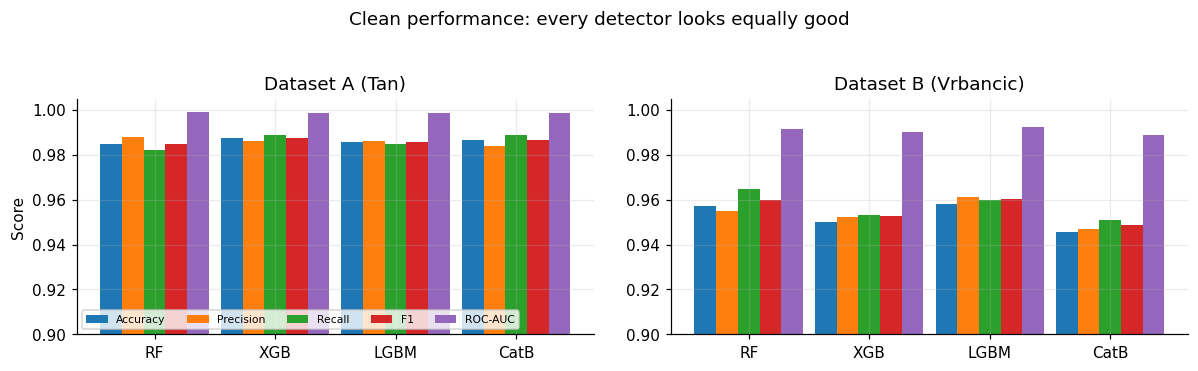

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
SHORT = {"RandomForest": "RF", "XGBoost": "XGB", "LightGBM": "LGBM", "CatBoost": "CatB"}

for ax, res, title in [(axs[0], resA, "Dataset A (Tan)"), (axs[1], resB, "Dataset B (Vrbancic)")]:
    x = np.arange(len(MODELS)); w = 0.18
    for k, (key, lab) in enumerate([("acc", "Accuracy"), ("prec", "Precision"),
                                    ("rec", "Recall"), ("f1", "F1"), ("auc", "ROC-AUC")]):
        ax.bar(x + (k - 2) * w, [res["clean"][m][key] for m in MODELS], w, label=lab)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[m] for m in MODELS])
    ax.set_ylim(0.90, 1.005); ax.set_title(title)

axs[0].set_ylabel("Score")
axs[0].legend(fontsize=7, ncol=5, loc="lower left")
plt.suptitle("Clean performance: every detector looks equally good", y=1.04)
plt.tight_layout(); plt.show()

### Figure 2 — Transfer robustness

This is the picture the whole paper is built around. Note the left panel falls off a cliff between
the first two points, while the right panel slopes down gently.

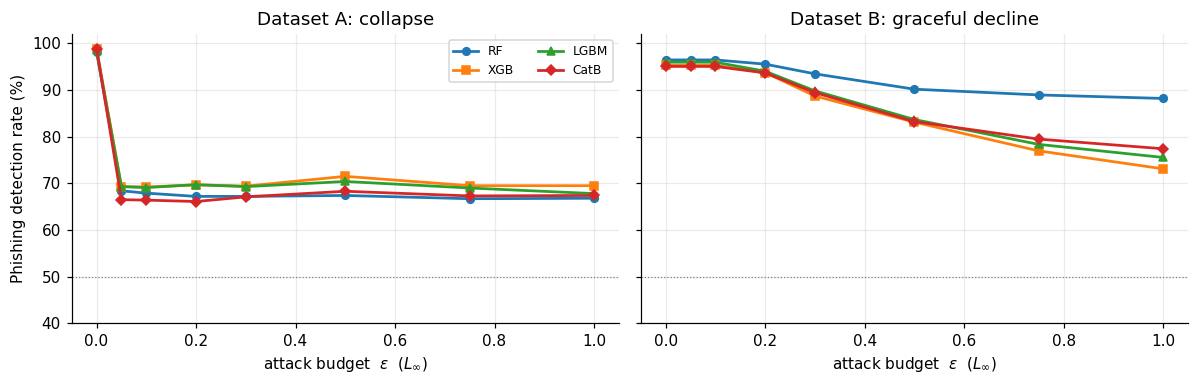

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
MK = {"RandomForest": "o", "XGBoost": "s", "LightGBM": "^", "CatBoost": "D"}

for ax, res, title in [(axs[0], resA, "Dataset A: collapse"),
                       (axs[1], resB, "Dataset B: graceful decline")]:
    for m in MODELS:
        ax.plot(res["eps"], [v * 100 for v in res["transfer"][m]],
                marker=MK[m], lw=1.8, ms=5, label=SHORT[m])
    ax.set_xlabel("attack budget  $\\epsilon$  ($L_\\infty$)")
    ax.set_ylim(40, 102); ax.set_title(title)
    ax.axhline(50, color="grey", lw=0.8, ls=":")

axs[0].set_ylabel("Phishing detection rate (%)")
axs[0].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### Figure 3 — Boundary attack curves and the price of evasion

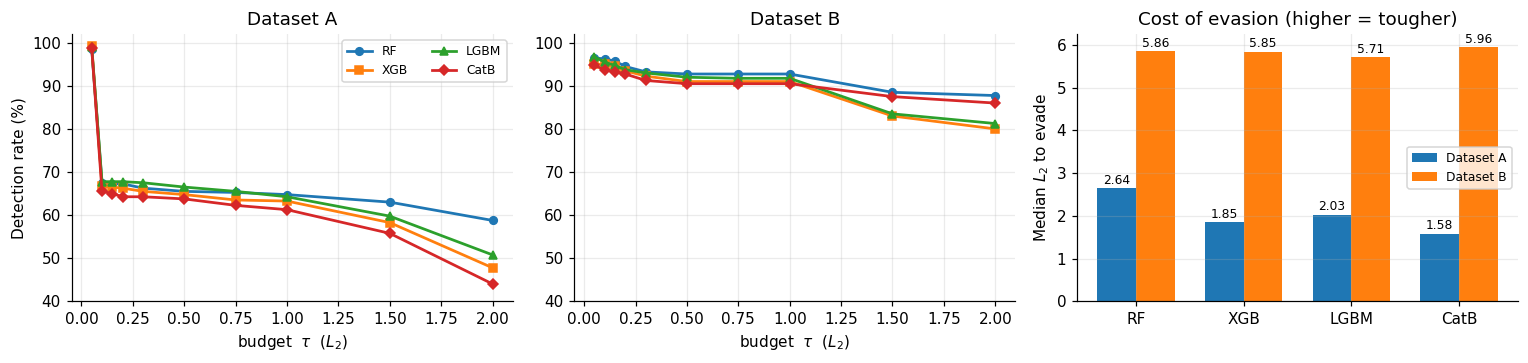

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.4))

for ax, res, title in [(axs[0], resA, "Dataset A"), (axs[1], resB, "Dataset B")]:
    for m in MODELS:
        ax.plot(res["taus"], [v * 100 for v in res["boundary"][m]["robust"]],
                marker=MK[m], lw=1.8, ms=5, label=SHORT[m])
    ax.set_xlabel("budget  $\\tau$  ($L_2$)"); ax.set_ylim(40, 102); ax.set_title(title)
axs[0].set_ylabel("Detection rate (%)"); axs[0].legend(fontsize=8, ncol=2)

x = np.arange(len(MODELS)); w = 0.36
a1 = [resA["boundary"][m]["med_l2"] for m in MODELS]
a2 = [resB["boundary"][m]["med_l2"] for m in MODELS]
axs[2].bar(x - w/2, a1, w, label="Dataset A")
axs[2].bar(x + w/2, a2, w, label="Dataset B")
for xi, v in zip(x - w/2, a1): axs[2].text(xi, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)
for xi, v in zip(x + w/2, a2): axs[2].text(xi, v + 0.1, f"{v:.2f}", ha="center", fontsize=8)
axs[2].set_xticks(x); axs[2].set_xticklabels([SHORT[m] for m in MODELS])
axs[2].set_ylabel("Median $L_2$ to evade"); axs[2].set_title("Cost of evasion (higher = tougher)")
axs[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Figure 4 — Feature reliance, and why accuracy misleads

The left panel is the explanation; the right panel is the warning. On the right, the Dataset B models
sit *lower* on accuracy but *higher* on evasion cost. Anyone picking a detector by accuracy alone
would have chosen the fragile one.

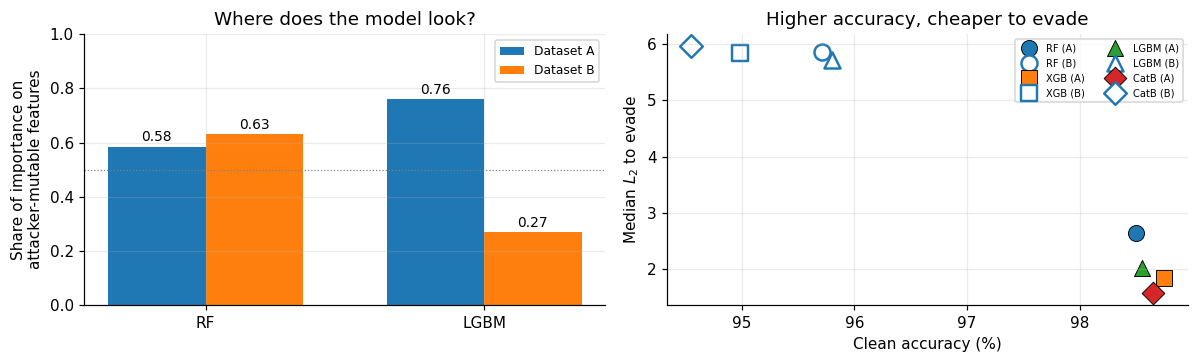

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))

pair = ["RandomForest", "LightGBM"]
x = np.arange(2); w = 0.35
v1 = [relA[m] for m in pair]; v2 = [relB[m] for m in pair]
b1 = axs[0].bar(x - w/2, v1, w, label="Dataset A")
b2 = axs[0].bar(x + w/2, v2, w, label="Dataset B")
for b, v in list(zip(b1, v1)) + list(zip(b2, v2)):
    axs[0].text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
axs[0].set_xticks(x); axs[0].set_xticklabels(["RF", "LGBM"]); axs[0].set_ylim(0, 1.0)
axs[0].axhline(0.5, color="grey", lw=0.8, ls=":")
axs[0].set_ylabel("Share of importance on\nattacker-mutable features")
axs[0].set_title("Where does the model look?"); axs[0].legend(fontsize=8)

for m in MODELS:
    axs[1].scatter(resA["clean"][m]["acc"] * 100, resA["boundary"][m]["med_l2"],
                   s=110, marker=MK[m], edgecolor="black", lw=0.6, label=f"{SHORT[m]} (A)")
    axs[1].scatter(resB["clean"][m]["acc"] * 100, resB["boundary"][m]["med_l2"],
                   s=110, marker=MK[m], facecolor="white", edgecolor="tab:blue", lw=1.6,
                   label=f"{SHORT[m]} (B)")
axs[1].set_xlabel("Clean accuracy (%)"); axs[1].set_ylabel("Median $L_2$ to evade")
axs[1].set_title("Higher accuracy, cheaper to evade")
axs[1].legend(fontsize=6.5, ncol=2)

plt.tight_layout(); plt.show()

### Figure 5 — Problem-space evasion and the defence trade-off

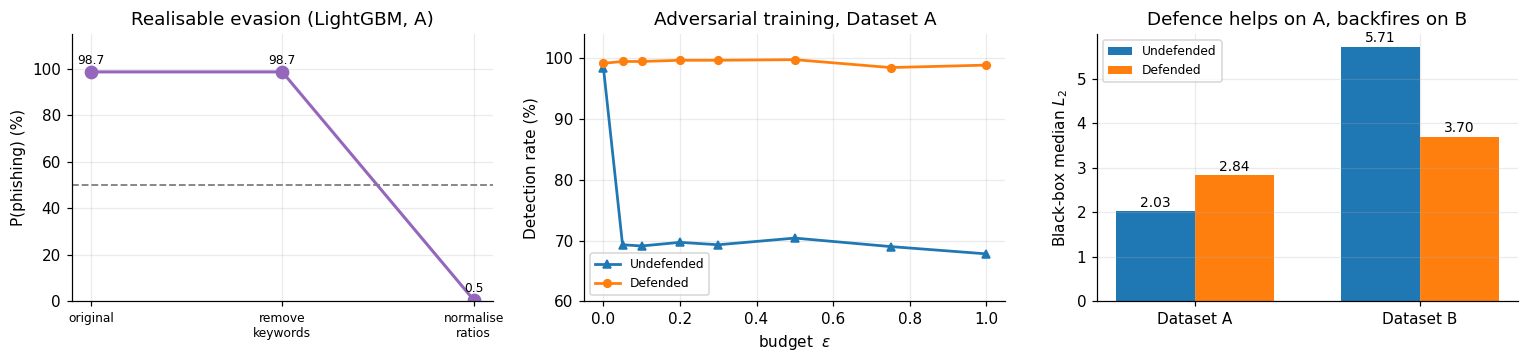

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.4))

# --- Subplot 1 ---
ps = [p * 100 for _, p in traj]; xr_ = np.arange(len(ps))
axs[0].plot(xr_, ps, marker="o", lw=2, ms=8, color="tab:purple")
axs[0].axhline(50, color="grey", lw=1.2, ls="--")
for xi, p in zip(xr_, ps):
    axs[0].text(xi, p + 3.5, f"{p:.1f}", ha="center", fontsize=8)

axs[0].set_xticks(xr_)
# Dynamically slice the labels to match the exact number of data points
all_labels = ["original", "remove\nkeywords", "normalise\nratios", "simplify\npunct."]
axs[0].set_xticklabels(all_labels[:len(xr_)], fontsize=8)

axs[0].set_ylim(0, 115); axs[0].set_ylabel("P(phishing) (%)")
axs[0].set_title("Realisable evasion (LightGBM, A)")

# --- Subplot 2 ---
d = resA["defense"]
axs[1].plot(resA["eps"], [v * 100 for v in d["undef"]], marker="^", lw=1.8, ms=5, label="Undefended")
axs[1].plot(resA["eps"], [v * 100 for v in d["defended"]], marker="o", lw=1.8, ms=5, label="Defended")
axs[1].set_xlabel("budget  $\\epsilon$"); axs[1].set_ylabel("Detection rate (%)")
axs[1].set_ylim(60, 104); axs[1].set_title("Adversarial training, Dataset A"); axs[1].legend(fontsize=8)

# --- Subplot 3 ---
labels = ["Dataset A", "Dataset B"]
before = [resA["boundary"]["LightGBM"]["med_l2"], resB["boundary"]["LightGBM"]["med_l2"]]
after = [resA["defense"]["boundary"]["med_l2"], resB["defense"]["boundary"]["med_l2"]]
xb = np.arange(2); w = 0.35

axs[2].bar(xb - w/2, before, w, label="Undefended")
axs[2].bar(xb + w/2, after, w, label="Defended")

for xi, v in zip(xb - w/2, before):
    axs[2].text(xi, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)
for xi, v in zip(xb + w/2, after):
    axs[2].text(xi, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)

axs[2].set_xticks(xb); axs[2].set_xticklabels(labels)
axs[2].set_ylabel("Black-box median $L_2$")
axs[2].set_title("Defence helps on A, backfires on B"); axs[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Step 13 — Save the results

Finally we write every measured number to a JSON file so the tables above can be regenerated without
re-running the experiments. In Colab you'll find it in the file browser on the left, or it downloads
automatically.

In [40]:
all_results = {
    "dataset_A": resA,
    "dataset_B": resB,
    "reliance": {"A": relA, "B": relB},
    "problem_space_trajectory": [{"step": n, "p_phish": p} for n, p in traj],
    "seed_runs": [{"seed": r["seed"], "clean": r["clean"],
                   "transfer": r["transfer"], "boundary": r["boundary"]} for r in runs],
}

with open("phishing_robustness_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Saved -> phishing_robustness_results.json")

# If we're on Colab, offer the file straight away.
try:
    from google.colab import files
    files.download("phishing_robustness_results.json")
except Exception:
    print("(Not running on Colab, so no automatic download. The file is in the working directory.)")

Saved -> phishing_robustness_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

Pulling the threads together:

1. **Clean accuracy told us nothing useful.** Every detector scored 94–99% and they were
   indistinguishable from each other. That number predicted neither how badly a model would fail
   under attack, nor which model would fail worst, nor whether a defence would help.

2. **Robustness depended on the dataset, not the algorithm.** Identical models and identical attacks
   collapsed on Dataset A (98.6% → mid-60s at a budget of 0.05) and held up on Dataset B (still
   above 88% at a budget of 1.0).

3. **The explanation is measurable.** LightGBM drew 76% of its importance from attacker-mutable
   features on the fragile dataset, against 27% on the robust one. When the signal lives in
   territory the attacker owns, evasion is cheap.

4. **The attack is realisable.** Six edits any phisher could make by hand took a page from
   P = 1.000 to a legitimate verdict.

5. **Defences need to be tested against an attacker they weren't trained on.** Adversarial training
   looked like a clean win under the transfer attack on both datasets, but the independent
   decision-based attacker showed it had actually made Dataset B *easier* to evade.

**The practical takeaway:** report robustness under a stated threat model alongside accuracy, and
prefer features an attacker cannot fabricate — host, DNS, registration age, TLS — over ones they
simply type.

---

### References

- Tan, C.L. (2018). *Phishing dataset for machine learning: feature evaluation.* Mendeley Data, V1.
- Vrbančič, G., Fister, I., Podgorelec, V. (2020). *Datasets for phishing websites detection.*
  Data in Brief, 33, 106438.
- Brendel, W., Rauber, J., Bethge, M. (2018). *Decision-based adversarial attacks.* ICLR.
- Madry, A. et al. (2018). *Towards deep learning models resistant to adversarial attacks.* ICLR.
- Papernot, N. et al. (2017). *Practical black-box attacks against machine learning.* ACM AsiaCCS.
- Pierazzi, F. et al. (2020). *Intriguing properties of adversarial ML attacks in the problem space.*
  IEEE S&P.
- Apruzzese, G., Conti, M., Yuan, Y. (2022). *SpacePhish.* ACSAC.
- Montaruli, B. et al. (2023). *Raze to the ground.* ACM AISec.